# Training Segmentation Model
Dataset: pseudo_dataset_08072026

## Prepare the training

In [1]:
import os
import re
import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, Model
from tensorflow.keras.layers import Conv2D, Dropout, Conv2DTranspose, Add

from tensorflow.keras.applications.vgg16 import preprocess_input

2026-07-11 07:37:02.177544: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
tf.config.list_physical_devices()
batch_size = 8
epochs = 20

## Dataloader

### Custom dataloader after splitting the dataset

In [3]:
%pwd

'/home/dionsetiawan/Documents/Riset/Progress-Tesis/thesis_ws/HaOri-6D/yon-poseCNN'

#### on training utility

In [4]:
def plot_training_history(history, save_path=None):
    history_dict = history.history

    metric_names = []

    for key in history_dict.keys():
        if not key.startswith("val_"):
            metric_names.append(key)

    n_metrics = len(metric_names)

    plt.figure(figsize=(7, 4 * n_metrics))

    for i, metric in enumerate(metric_names):
        plt.subplot(n_metrics, 1, i + 1)

        train_values = history_dict[metric]
        plt.plot(train_values, label=f"train_{metric}")

        val_metric = "val_" + metric
        if val_metric in history_dict:
            val_values = history_dict[val_metric]
            plt.plot(val_values, label=val_metric)

        plt.title(metric)
        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.legend()
        plt.grid(True)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved training curve to:", save_path)

    plt.show()

#### aditional data utility

In [5]:
def reverse_vgg_preprocess(image):
    """
    Mengembalikan image dari VGG16 preprocess_input ke RGB 0-1 untuk visualisasi.
    """
    image = image.copy()

    # Add mean BGR
    image[..., 0] += 103.939
    image[..., 1] += 116.779
    image[..., 2] += 123.68

    # BGR to RGB
    image = image[..., ::-1]

    image = np.clip(image, 0, 255)
    image = image / 255.0

    return image

def natural_key(path):
    basename = os.path.basename(path)
    return [
        int(text) if text.isdigit() else text.lower()
        for text in re.split(r"(\d+)", basename)
    ]


def list_files(folder, extensions):
    files = [
        os.path.join(folder, fname)
        for fname in os.listdir(folder)
        if fname.lower().endswith(extensions)
    ]

    return sorted(files, key=natural_key)


def find_column(df, candidates):
    normalized = {}

    for col in df.columns:
        key = col.lower().replace(" ", "").replace("-", "").replace("_", "")
        normalized[key] = col

    for cand in candidates:
        key = cand.lower().replace(" ", "").replace("-", "").replace("_", "")

        if key in normalized:
            return normalized[key]

    return None

def check_image_size(path, expected_size=(720, 1280)):
    img = cv2.imread(path)

    if img is None:
        raise ValueError(f"Gagal membaca file: {path}")

    h, w = img.shape[:2]

    if (h, w) != expected_size:
        raise ValueError(
            f"Ukuran image tidak sesuai: {path}\n"
            f"Expected: {expected_size}\n"
            f"Got     : {(h, w)}"
        )

    return h, w

def list_files(folder, exts):
    return sorted(
        [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith(exts)
        ],
        key=natural_key
    )

def remove_mask_suffix(stem):
    suffixes = [
        "_sam_mask",
        "_mask",
        "_semantic",
        "_segmentation"
    ]

    for suffix in suffixes:
        if stem.endswith(suffix):
            stem = stem[: -len(suffix)]

    return stem

In [6]:
def build_image_mask_pairs(
    dataset_root,
    image_subdir="img_left",
    mask_subdir="semantic_new",
    pair_mode="stem"
):
    image_dir = os.path.join(dataset_root, image_subdir)
    mask_dir = os.path.join(dataset_root, mask_subdir)

    image_paths = list_files(image_dir, (".jpg", ".jpeg", ".png"))
    mask_paths = list_files(mask_dir, (".png", ".jpg", ".jpeg"))

    if pair_mode == "order":
        n = min(len(image_paths), len(mask_paths))
        return image_paths[:n], mask_paths[:n]

    elif pair_mode == "stem":
        mask_map = {}

        for mask_path in mask_paths:
            stem = os.path.splitext(os.path.basename(mask_path))[0]
            stem = remove_mask_suffix(stem)
            mask_map[stem] = mask_path

        paired_images = []
        paired_masks = []

        for image_path in image_paths:
            image_stem = os.path.splitext(os.path.basename(image_path))[0]

            if image_stem in mask_map:
                paired_images.append(image_path)
                paired_masks.append(mask_map[image_stem])

        return paired_images, paired_masks

    else:
        raise ValueError("pair_mode harus 'stem' atau 'order'.")
    

def load_segmentation_pair(image_path, mask_path, image_size=(224, 224)):
    image = tf.io.read_file(image_path)
    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        image_size,
        method="bilinear"
    )
    image = tf.cast(image, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.io.decode_image(
        mask,
        channels=1,
        expand_animations=False
    )
    mask.set_shape([None, None, 1])

    mask = tf.image.resize(
        mask,
        image_size,
        method="nearest"
    )

    mask = tf.cast(mask > 127, tf.float32)

    return image, mask


def make_segmentation_dataloader(
    dataset_root,
    image_subdir="img_left",
    mask_subdir="semantic_new",
    image_size=(224, 224),
    batch_size=8,
    val_ratio=0.2,
    seed=42,
    pair_mode="stem",
    shuffle=True
):
    image_paths, mask_paths = build_image_mask_pairs(
        dataset_root=dataset_root,
        image_subdir=image_subdir,
        mask_subdir=mask_subdir,
        pair_mode=pair_mode
    )

    image_paths = np.array(image_paths)
    mask_paths = np.array(mask_paths)

    print("Total image:", len(image_paths))
    print("Total mask :", len(mask_paths))

    if len(image_paths) == 0:
        raise ValueError("Tidak ada pasangan image-mask yang ditemukan.")

    rng = np.random.default_rng(seed)
    indices = np.arange(len(image_paths))
    rng.shuffle(indices)

    image_paths = image_paths[indices]
    mask_paths = mask_paths[indices]

    val_count = int(len(image_paths) * val_ratio)

    val_images = image_paths[:val_count]
    val_masks = mask_paths[:val_count]

    train_images = image_paths[val_count:]
    train_masks = mask_paths[val_count:]

    train_ds = tf.data.Dataset.from_tensor_slices(
        (train_images, train_masks)
    )

    val_ds = tf.data.Dataset.from_tensor_slices(
        (val_images, val_masks)
    )

    if shuffle:
        train_ds = train_ds.shuffle(
            buffer_size=len(train_images),
            seed=seed
        )

    train_ds = train_ds.map(
        lambda img, msk: load_segmentation_pair(
            img,
            msk,
            image_size=image_size
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    val_ds = val_ds.map(
        lambda img, msk: load_segmentation_pair(
            img,
            msk,
            image_size=image_size
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_ds, val_ds

#### call data loader

In [7]:
%pwd

'/home/dionsetiawan/Documents/Riset/Progress-Tesis/thesis_ws/HaOri-6D/yon-poseCNN'

In [8]:
train_dataset, validation_dataset = make_segmentation_dataloader(
    dataset_root="./data-extraction/pseudo_dataset_08072026",
    image_subdir="img_left",
    mask_subdir="semantic",
    image_size=(224, 224),
    batch_size=batch_size,
    val_ratio=0.2,
    pair_mode="order"
)

Total image: 5972
Total mask : 5972


I0000 00:00:1783730226.389665   29499 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2142 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


## Additional Metrics (Optional)

In [1]:
@tf.keras.utils.register_keras_serializable(package="SegmentationMetrics")
def dice_coefficient(y_true, y_pred, threshold=0.5, smooth=1e-7):
    """
    Menghitung hard Dice coefficient per gambar,
    kemudian mengambil rata-rata seluruh gambar dalam batch.
    """

    y_true = tf.cast(y_true >= 0.5, tf.float32)
    y_pred = tf.cast(y_pred >= threshold, tf.float32)

    # Bentuk data menjadi [batch_size, total_pixels]
    y_true = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

    intersection = tf.reduce_sum(y_true * y_pred, axis=1)

    denominator = (
        tf.reduce_sum(y_true, axis=1)
        + tf.reduce_sum(y_pred, axis=1)
    )

    dice_per_image = (
        2.0 * intersection + smooth
    ) / (
        denominator + smooth
    )

    return tf.reduce_mean(dice_per_image)


@tf.keras.utils.register_keras_serializable(package="SegmentationMetrics")
def intersection_over_union(y_true, y_pred, threshold=0.5, smooth=1e-7):
    """
    Menghitung hard IoU per gambar,
    kemudian mengambil rata-rata seluruh gambar dalam batch.
    """

    y_true = tf.cast(y_true >= 0.5, tf.float32)
    y_pred = tf.cast(y_pred >= threshold, tf.float32)

    y_true = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

    intersection = tf.reduce_sum(y_true * y_pred, axis=1)

    total_area = (
        tf.reduce_sum(y_true, axis=1)
        + tf.reduce_sum(y_pred, axis=1)
    )

    union = total_area - intersection

    iou_per_image = (
        intersection + smooth
    ) / (
        union + smooth
    )

    return tf.reduce_mean(iou_per_image)

NameError: name 'tf' is not defined

## Training segmentation model using VGG16-Mirrored (segnet)

In [10]:
model1_name = 'SegNet_semantic_new'

### Architecture

In [11]:
def vgg_network(input_shape=(256, 256, 3), num_classes=1):
    """
    Create a VGG16-based segmentation model.

    Args:
    input_shape (tuple): Shape of the input image. Default is (224, 224, 3).
    num_classes (int): Number of output classes. Default is 1 for binary segmentation.

    Returns:
    model (tf.keras.Model): VGG16-based segmentation model.
    """
    threshold = 0.5
    
    # Load the VGG16 model without the top layers
    vgg16 = VGG16(weights='imagenet', 
                  include_top=False, 
                  input_shape=input_shape)

    # Freeze the VGG16 layers
    for layer in vgg16.layers:
        layer.trainable = False
        
    # Encoder (bottleneck): Use the output of the last convolutional block of VGG16
    x = vgg16.output  # Shape: (None, 7, 7, 512)
    
    # Decoder: Add up-sampling layers - Deconvolution
    x = layers.UpSampling2D((2, 2), name='d_block7_upsample')(x) # Shape: (None, 14, 14, 512)
    x = layers.Conv2D(512, (3, 3), activation="relu", padding="same",name='d_block7_conv1')(x)
    x = layers.Conv2D(512, (3, 3), activation="relu", padding="same",name='d_block7_conv2')(x)
    x = layers.Conv2D(512, (3, 3), activation="relu", padding="same",name='d_block7_conv3')(x)

    x = layers.UpSampling2D((2, 2), name='d_block8_upsample')(x) # Shape: (None, 28, 28, 512) 
    x = layers.Conv2D(512, (3, 3), activation="relu", padding="same",name='d_block8_conv1')(x)
    x = layers.Conv2D(512, (3, 3), activation="relu", padding="same",name='d_block8_conv2')(x)
    x = layers.Conv2D(512, (3, 3), activation="relu", padding="same",name='d_block8_conv3')(x)

    x = layers.UpSampling2D((2, 2), name='d_block9_upsample')(x) # Shape: (None, 56, 56, 256)
    x = layers.Conv2D(256, (3, 3), activation="relu", padding="same",name='d_block9_conv1')(x)
    x = layers.Conv2D(256, (3, 3), activation="relu", padding="same",name='d_block9_conv2')(x)
    x = layers.Conv2D(256, (3, 3), activation="relu", padding="same",name='d_block9_conv3')(x)

    x = layers.UpSampling2D((2, 2), name='d_block10_upsample')(x) # Shape: (None, 112, 112, 128)
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same",name='d_block10_conv1')(x)
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same",name='d_block10_conv2')(x)

    x = layers.UpSampling2D((2, 2), name='d_block11_upsample')(x) # Shape: (None, 224, 224, 64)
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same",name='d_block11_conv1')(x)
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same",name='d_block11_conv2')(x)
    
    # Final segmentation layer
    activation = 'sigmoid' if num_classes == 1 else 'softmax'
    output = Conv2D(num_classes, (1, 1), activation=activation, name='output')(x)

    # Create the model
    model = tf.keras.models.Model(inputs=vgg16.input, outputs=output, name=model1_name)

    # # Compile the model
    # model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', keras.metrics.BinaryCrossentropy()])
    
    return model

### Define model

In [12]:
# Define model
model1 = vgg_network(input_shape=(224, 224, 3), num_classes=1)
model1.summary()

Model: "SegNet_semantic_new"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_block7_upsample               │ (None, 14, 14, 512)    │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_block7_conv1 (Conv2D)         │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_block7_conv2 (Conv2D)         │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_block7_conv3 (Conv2D)         │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d_block8_upsample               │ (None, 28, 28, 512)    │             0 │
│ (UpSampling2D)                  │                        │             

 Total params: 31,787,009 (121.26 MB)

 Trainable params: 17,072,321 (65.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Tensorboard callback

In [13]:
from datetime import datetime

# Create TensorBoard callback
current_time = datetime.now().strftime("%Y%m%d-%H%M%S")
log_dirs = "./Semantic-New-Dion/runs/runVGG16/logs/" + model1_name + "_" + current_time
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dirs, histogram_freq=1)
print("Saving log to:", log_dirs)

Saving log to: ./Semantic-New-Dion/runs/runVGG16/logs/SegNet_semantic_new_20260711-073708


### Model Training, Evaluating, and Predicting

#### Compiling

In [14]:
# Compiling the model
model1.compile(optimizer='adam', 
               loss='binary_crossentropy', 
               metrics=[
                   dice_coefficient,
                    intersection_over_union]
                )

#### Fitting (training) and evaluating (testing)

In [15]:
# Train model
history1 = model1.fit(train_dataset, 
                      validation_data=validation_dataset, 
                      batch_size=batch_size,
                      epochs=epochs, 
                      callbacks=[tensorboard_callback])

Epoch 1/20


2026-07-11 07:37:11.496727: I external/local_xla/xla/service/service.cc:163] XLA service 0x741d54009b80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-07-11 07:37:11.496886: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-07-11 07:37:11.663986: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-07-11 07:37:12.552767: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92400
2026-07-11 07:37:13.855328: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.28GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-07-11 07:37:14.85838

598/598 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - dice_coefficient: 0.5692 - intersection_over_union: 0.4835 - loss: 0.5612

2026-07-11 07:41:58.598193: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 283115520 exceeds 10% of free system memory.
2026-07-11 07:41:58.743961: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 566231040 exceeds 10% of free system memory.
2026-07-11 07:41:59.008316: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 566231040 exceeds 10% of free system memory.
2026-07-11 07:41:59.276223: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 566231040 exceeds 10% of free system memory.
2026-07-11 07:41:59.550695: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 566231040 exceeds 10% of free system memory.


598/598 ━━━━━━━━━━━━━━━━━━━━ 293s 431ms/step - dice_coefficient: 0.7652 - intersection_over_union: 0.6651 - loss: 0.1363 - val_dice_coefficient: 0.8609 - val_intersection_over_union: 0.7605 - val_loss: 0.0374
Epoch 2/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 247s 413ms/step - dice_coefficient: 0.8899 - intersection_over_union: 0.8058 - loss: 0.0307 - val_dice_coefficient: 0.9068 - val_intersection_over_union: 0.8329 - val_loss: 0.0271
Epoch 3/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 240s 402ms/step - dice_coefficient: 0.9092 - intersection_over_union: 0.8373 - loss: 0.0253 - val_dice_coefficient: 0.9099 - val_intersection_over_union: 0.8376 - val_loss: 0.0250
Epoch 4/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 228s 382ms/step - dice_coefficient: 0.9201 - intersection_over_union: 0.8550 - loss: 0.0225 - val_dice_coefficient: 0.9232 - val_intersection_over_union: 0.8600 - val_loss: 0.0219
Epoch 5/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 229s 383ms/step - dice_coefficient: 0.9274 - intersection_over_union: 0.8672 - loss: 0.0205

In [16]:
results = model1.evaluate(
    validation_dataset,
    return_dict=True,
    verbose=1
)

print("\nSegmentation evaluation")
print("-" * 40)

for metric_name, metric_value in results.items():
    print(f"{metric_name:30s}: {metric_value:.4f}")

150/150 ━━━━━━━━━━━━━━━━━━━━ 24s 158ms/step - dice_coefficient: 0.9551 - intersection_over_union: 0.9154 - loss: 0.0131

Segmentation evaluation
----------------------------------------
dice_coefficient              : 0.9551
intersection_over_union       : 0.9154
loss                          : 0.0131


#### Saving model

In [17]:
# Save the model
# log_dirs = "./Semantic-New-Dion/runs/runVGG16/logs/" + model1_name + current_time
dirpath = './Semantic-New-Dion/runs/runVGG16/weights/'
filename = model1_name + '_' + current_time + '.keras'
save_to = dirpath + filename
print('Saving to directory:', save_to)
model1.save(save_to)

Saving to directory: ./Semantic-New-Dion/runs/runVGG16/weights/SegNet_semantic_new_20260711-073708.keras


#### Predicting with VGG16 mirror-decoder 

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
(224, 224, 1)


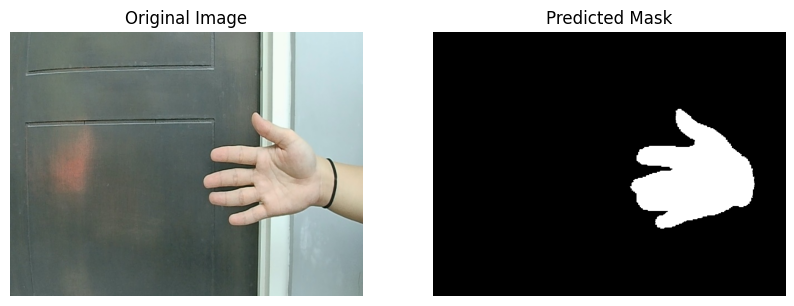

In [18]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load the trained model
# model1 = tf.keras.models.load_model(
#     './Semantic-New-Dion/runs/runVGG16/weights/VGG16_semantic_new_20260702-231818.keras')
# model1.summary()

def load_and_preprocess_image(image_path, image_size=(224, 224)):
    """
    Loads and preprocesses the image for the model.
    """
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    # # Convert TensorFlow image to numpy array for OpenCV processing
    # image_np = image.numpy()
    # # Apply Gaussian filter
    # image_np = cv2.GaussianBlur(image_np, (5, 5), 0)
    # # Convert back to TensorFlow tensor
    # image = tf.convert_to_tensor(image_np)
    
    image = tf.image.resize(image, image_size)
    image = tf.cast(image, tf.float32) / 255.0
    return image

def predict_segmentation(model, image_path, image_size=(224, 224)):
    """
    Predicts the segmentation mask for a given image.
    """
    # Load and preprocess the image
    image = load_and_preprocess_image(image_path, image_size)
    image = tf.expand_dims(image, axis=0)  # Add batch dimension

    # Predict the segmentation mask
    predicted_mask = model.predict(image)[0]  # Remove batch dimension
    threshold = 0.5
    binary_mask = (predicted_mask > threshold).astype(np.uint8)
    return binary_mask

def display_image_and_mask(image_path, predicted_mask):
    """
    Displays the original image and the predicted mask.
    """
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB for display

    # Resize the image to match the mask size
    print(predicted_mask.shape)
    predicted_mask_resized = cv2.resize(predicted_mask, (image.shape[1], image.shape[0]))

    # Display the image and mask
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title('Original Image')
    plt.imshow(image)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title('Predicted Mask')
    plt.imshow(predicted_mask_resized, cmap='gray')
    plt.axis('off')

    plt.show()

# Path to the test image
test_image_path = 'data/A-splitdataset/test/images/amik-img-3-M-frame-6-2024-06-07_234757_0.jpg'
# test_image_path = 'data/A-splitdataset/test/images/bryan-img-5-M-frame-132-2024-06-07_234942_0.jpg'
# test_image_path = 'data/A-splitdataset/test/images/dion-img-3-M-frame-336-2024-06-07_235425_0.jpg'

# test_image_path = 'data/A-splitdataset/test/images/ema-img-6-M-frame-308-2024-06-07_235705_0.jpg'
# test_image_path = 'data/A-splitdataset/test/images/iwap-img-6-M-frame-204-2024-06-07_235838_0.jpg'
# test_image_path = 'data/A-splitdataset/test/images/umam-img-3-M-frame-395-2024-06-08_000005_0.jpg'

# Predict the segmentation mask
predicted_mask = predict_segmentation(model1, test_image_path, image_size=(224, 224))

# Display the original image and the predicted mask
display_image_and_mask(test_image_path, predicted_mask)

## Training segmentation using Baseline PoseCNN's decoder

In [19]:
model2_name = 'poseCNN-base_semantic_new'

### Architecture

In [20]:
from tensorflow.keras.applications import VGG16

# Define the feature extraction part using VGG16
def PoseCNNBaseLine(input_shape, num_classes):
    
    # Load the VGG16 model without the top layers
    vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze the VGG16 layers
    for layer in vgg16.layers:
        layer.trainable = False
    
    # Extract specific layers to match the diagram
    block4_conv3 = vgg16.get_layer('block4_conv3').output
    block5_conv3 = vgg16.get_layer('block5_conv3').output
    
    '''
        Decoder
    '''
    # block5_conv3 upsampling
    SBk = Conv2D(64, kernel_size=(1, 1), activation='relu', padding='same')(block5_conv3)  # 1/16
    SBk = Conv2DTranspose(64, kernel_size=(4, 4), strides=2, padding='same')(SBk) # Deconv layer
    # SBk = Conv2D(64, kernel_size=(1, 1), activation='relu', padding='same')(SBk)  # 1/8

    # block4_conv3 
    SBb = Conv2D(64, kernel_size=(1, 1), activation='relu', padding='same')(block4_conv3) # 1/8

    # Add upsampled features
    xS  = Add()([SBk, SBb])
    xS  = Dropout(0.5)(xS)
    
    # Last upsampling
    xS  = Conv2DTranspose(64, kernel_size=(16, 16), strides=8, padding='same')(xS) # Deconv layer  # 1/4 to 1/1
    
    # Final segmentation layer
    segmentation_layer = Conv2D(1, kernel_size=1, activation='sigmoid', padding='same')(xS)
    
    # Create the model
    model = tf.keras.models.Model(inputs=vgg16.input, outputs=segmentation_layer, name=model2_name)

    return model

### Define Model VGG16-PoseCNN decoder baseline

In [21]:
# Example usage:
model2 = PoseCNNBaseLine(input_shape=(224, 224, 3), num_classes=1)
model2.summary()

Model: "poseCNN-base_semantic_new"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer_1[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 15,894,657 (60.63 MB)

 Trainable params: 1,179,969 (4.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Callback tensorboard

In [22]:
from datetime import datetime
current_time = datetime.now().strftime("%Y%m%d-%H%M%S")
log_dir = "./Semantic-New-Dion/runs/runPoseCNN/logs/" + model2_name + "_" + current_time
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
print("Saving log to:", log_dir)

Saving log to: ./Semantic-New-Dion/runs/runPoseCNN/logs/poseCNN-base_semantic_new_20260711-085733


### Model Training, Evaluating and Predicting

#### Compiling

In [23]:
# Compile the model
model2.compile(optimizer='adam', 
               loss='binary_crossentropy', 
               metrics=[
                   dice_coefficient,
                    intersection_over_union]
                )

#### Fitting (training) and Evaulating (testing)

In [24]:
# Train model
history2 = model2.fit(train_dataset, 
                      validation_data=validation_dataset, 
                      epochs=epochs, 
                      batch_size=batch_size,
                      callbacks=[tensorboard_callback])

Epoch 1/20


2026-07-11 08:57:37.224239: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv (f32[8,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,64,28,28]{3,2,1,0}, f32[64,64,16,16]{3,2,1,0}), window={size=16x16 stride=8x8 pad=4_4x4_4}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-07-11 08:57:45.642281: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 9.41814413s
Trying algorithm eng0{} for conv (f32[8,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,64,28,28]{3,2,1,0}, f32[64,64,16,16]{3,2,1,0}), window={size=16x16 stride=8x8 pad=4_4x4_4}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_

597/598 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - dice_coefficient: 0.7576 - intersection_over_union: 0.6651 - loss: 0.0752

2026-07-11 08:58:41.732817: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv (f32[2,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[2,64,28,28]{3,2,1,0}, f32[64,64,16,16]{3,2,1,0}), window={size=16x16 stride=8x8 pad=4_4x4_4}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-07-11 08:58:43.136336: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 2.403573099s
Trying algorithm eng0{} for conv (f32[2,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[2,64,28,28]{3,2,1,0}, f32[64,64,16,16]{3,2,1,0}), window={size=16x16 stride=8x8 pad=4_4x4_4}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend

598/598 ━━━━━━━━━━━━━━━━━━━━ 86s 118ms/step - dice_coefficient: 0.8638 - intersection_over_union: 0.7805 - loss: 0.0395 - val_dice_coefficient: 0.9241 - val_intersection_over_union: 0.8621 - val_loss: 0.0217
Epoch 2/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 64s 107ms/step - dice_coefficient: 0.9198 - intersection_over_union: 0.8550 - loss: 0.0224 - val_dice_coefficient: 0.9361 - val_intersection_over_union: 0.8821 - val_loss: 0.0187
Epoch 3/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 64s 108ms/step - dice_coefficient: 0.9279 - intersection_over_union: 0.8685 - loss: 0.0201 - val_dice_coefficient: 0.9408 - val_intersection_over_union: 0.8901 - val_loss: 0.0172
Epoch 4/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 64s 108ms/step - dice_coefficient: 0.9325 - intersection_over_union: 0.8762 - loss: 0.0188 - val_dice_coefficient: 0.9446 - val_intersection_over_union: 0.8967 - val_loss: 0.0161
Epoch 5/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 65s 108ms/step - dice_coefficient: 0.9356 - intersection_over_union: 0.8816 - loss: 0.0179 - va

In [25]:
results = model2.evaluate(
    validation_dataset,
    return_dict=True,
    verbose=1
)

print("\nSegmentation evaluation")
print("-" * 40)

for metric_name, metric_value in results.items():
    print(f"{metric_name:30s}: {metric_value:.4f}")

150/150 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - dice_coefficient: 0.9572 - intersection_over_union: 0.9192 - loss: 0.0126

Segmentation evaluation
----------------------------------------
dice_coefficient              : 0.9572
intersection_over_union       : 0.9192
loss                          : 0.0126


#### Saving model

In [26]:
# Save the model
dirpath = './Semantic-New-Dion/runs/runPoseCNN/weights/'
filename = model2_name + '_' + current_time + '.keras'
save_to = dirpath + filename
print('Saving to directory:', save_to)
model2.save(save_to)

Saving to directory: ./Semantic-New-Dion/runs/runPoseCNN/weights/poseCNN-base_semantic_new_20260711-085733.keras


#### Predicting with PoseCNN baseline decoder

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
(224, 224, 1)


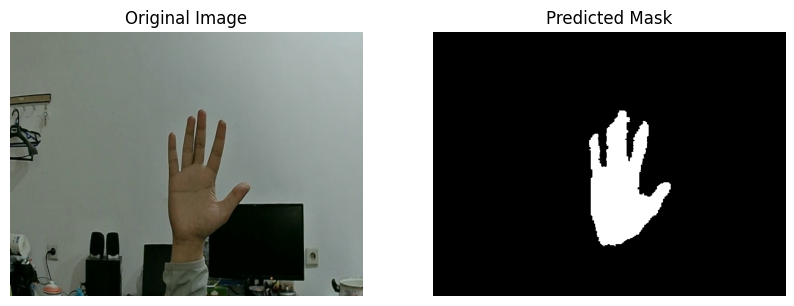

In [34]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load the trained model
# model2 = tf.keras.models.load_model(
#             './Semantic-New-Dion/runs/runPoseCNN/weights/poseCNN-base_semantic_new.keras')

def load_and_preprocess_image(image_path, image_size=(256, 256)):
    """
    Loads and preprocesses the image for the model.
    """
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)

    # # Convert TensorFlow image to numpy array for OpenCV processing
    # image_np = image.numpy()
    # # Apply Gaussian filter
    # image_np = cv2.GaussianBlur(image_np, (5, 5), 0)
    # # Convert back to TensorFlow tensor
    # image = tf.convert_to_tensor(image_np)
    
    image = tf.image.resize(image, image_size)
    image = tf.cast(image, tf.float32) / 255.0
    return image

def predict_segmentation(model2, image_path, image_size=(256, 256), load_model=True):
    """
    Predicts the segmentation mask for a given image.
    """
    if load_model:
        model2 = tf.keras.models.load_model(
            './Semantic-New-Dion/runs/runPoseCNN/weights/poseCNN-base_semantic_new.keras')
        model2.summary()
    # Load and preprocess the image
    image = load_and_preprocess_image(image_path, image_size)
    image = tf.expand_dims(image, axis=0)  # Add batch dimension

    # Predict the segmentation mask
    predicted_mask = model2.predict(image)[0]  # Remove batch dimension
    threshold = 0.3
    binary_mask = (predicted_mask > threshold).astype(np.uint8)
    return binary_mask

def display_image_and_mask(image_path, predicted_mask):
    """
    Displays the original image and the predicted mask.
    """
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB for display

    # Resize the image to match the mask size
    print(predicted_mask.shape)
    predicted_mask_resized = cv2.resize(predicted_mask, (image.shape[1], image.shape[0]))

    # Display the image and mask
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title('Original Image')
    plt.imshow(image)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title('Predicted Mask')
    plt.imshow(predicted_mask_resized, cmap='gray')
    plt.axis('off')

    plt.show()
    
test_image_path = 'data/A-splitdataset/test/images/amik-img-3-M-frame-6-2024-06-07_234757_0.jpg'
test_image_path = 'data/A-splitdataset/test/images/bryan-img-5-M-frame-132-2024-06-07_234942_0.jpg'
test_image_path = 'data/A-splitdataset/test/images/dion-img-3-M-frame-336-2024-06-07_235425_0.jpg'

# test_image_path = 'data/A-splitdataset/test/images/ema-img-6-M-frame-308-2024-06-07_235705_0.jpg'
# test_image_path = 'data/A-splitdataset/test/images/iwap-img-6-M-frame-204-2024-06-07_235838_0.jpg'
# test_image_path = 'data/A-splitdataset/test/images/umam-img-3-M-frame-395-2024-06-08_000005_0.jpg'

# Predict the segmentation mask
predicted_mask = predict_segmentation(model2, test_image_path, image_size=(224, 224), 
                                      load_model=False)

# Display the original image and the predicted mask
display_image_and_mask(test_image_path, predicted_mask)

## Training segmentation using Modified-poseCNN's decoder

In [28]:
model3_name = 'Modified_PoseCNN_Semantic'

### Architecture

In [29]:
from tensorflow.keras.applications import VGG16

# Define the feature extraction part using VGG16
def ModifiedPoseCNN(input_shape, num_classes):
    
    # Load the VGG16 model without the top layers
    vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze the VGG16 layers
    for layer in vgg16.layers:
        layer.trainable = False
    
    # Extract specific layers to match the diagram
    block4_conv3 = vgg16.get_layer('block4_conv3').output
    block5_conv3 = vgg16.get_layer('block5_conv3').output
    
    '''
        Decoder
    '''
    # block5_conv3 upsampling
    SBk = Conv2D(64, kernel_size=(1, 1), activation='relu', padding='same')(block5_conv3)  # 1/16
    SBk = Conv2DTranspose(64, kernel_size=(3, 3), strides=2, padding='same')(SBk) # Deconv layer
    SBk = Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same')(SBk)  # 1/8
    
    # block4_conv3 upsampling
    SBb = Conv2D(64, kernel_size=(1, 1), activation='relu', padding='same')(block4_conv3) # 1/8
    xS  = Add()([SBk, SBb])
    xS  = Dropout(0.5)(xS)
    xS  = Conv2DTranspose(64, kernel_size=(3, 3), strides=2, padding='same')(xS) # Deconv layer  # 1/4
    xS  = Conv2D(64, kernel_size=(1, 1), activation='relu', padding='same')(xS)  # 1/4
    
    xS  = Conv2DTranspose(64, kernel_size=(3, 3), strides=2, padding='same')(xS) # Deconv layer # 1/2
    xS  = Conv2D(64, kernel_size=(1, 1), activation='relu', padding='same')(xS)  # 1/2
    
    xS  = Conv2DTranspose(64, kernel_size=(3, 3), strides=2, padding='same')(xS) # Deconv layer # 1/1
    xS  = Conv2D(64, kernel_size=(1, 1), activation='relu', padding='same')(xS)  # 1/1
    
    # Final segmentation layer
    segmentation_layer = Conv2D(1, kernel_size=(1, 1), activation='sigmoid', padding='same')(xS)
    
    # Create the model
    model = tf.keras.models.Model(inputs=vgg16.input, 
                                  outputs=segmentation_layer,
                                  name=model3_name)

    return model


### Define model

In [30]:
# Example usage:
model3 = ModifiedPoseCNN(input_shape=(224, 224, 3), num_classes=1)
model3.summary()

Model: "Modified_PoseCNN_Semantic"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer_2[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 14,977,537 (57.13 MB)

 Trainable params: 262,849 (1.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Callback tensorboard

In [31]:
from datetime import datetime

# Create TensorBoard callback
current_time = datetime.now().strftime("%Y%m%d-%H%M%S")
log_dirs = "./Semantic-New-Dion/runs/Modified-PoseCNN/logs/" + model3_name + "_" + current_time

tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dirs, histogram_freq=1)
print("Saving log to:", log_dirs)

Saving log to: ./Semantic-New-Dion/runs/Modified-PoseCNN/logs/Modified_PoseCNN_Semantic_20260711-091944


### Model Training, Evaluating and Predicting

#### Compiling

In [32]:
# Compile the model
model3.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=[
                  dice_coefficient,
                  intersection_over_union]
              )

#### Fitting

In [35]:
# Train model
history3 = model3.fit(train_dataset, 
                      validation_data=validation_dataset, 
                      batch_size = batch_size,
                      epochs=epochs, callbacks=[tensorboard_callback])

Epoch 1/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 86s 124ms/step - dice_coefficient: 0.7556 - intersection_over_union: 0.6860 - loss: 0.0508 - val_dice_coefficient: 0.9242 - val_intersection_over_union: 0.8617 - val_loss: 0.0219
Epoch 2/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 69s 115ms/step - dice_coefficient: 0.9197 - intersection_over_union: 0.8545 - loss: 0.0225 - val_dice_coefficient: 0.9353 - val_intersection_over_union: 0.8806 - val_loss: 0.0186
Epoch 3/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 71s 119ms/step - dice_coefficient: 0.9283 - intersection_over_union: 0.8689 - loss: 0.0200 - val_dice_coefficient: 0.9427 - val_intersection_over_union: 0.8935 - val_loss: 0.0166
Epoch 4/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 72s 120ms/step - dice_coefficient: 0.9339 - intersection_over_union: 0.8784 - loss: 0.0184 - val_dice_coefficient: 0.9468 - val_intersection_over_union: 0.9007 - val_loss: 0.0157
Epoch 5/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 73s 122ms/step - dice_coefficient: 0.9370 - intersection_over_union: 0.8838 - loss: 

#### Evaluating model

In [36]:
results = model3.evaluate(
    validation_dataset,
    return_dict=True,
    verbose=1
)

print("\nSegmentation evaluation")
print("-" * 40)

for metric_name, metric_value in results.items():
    print(f"{metric_name:30s}: {metric_value:.4f}")

  1/150 ━━━━━━━━━━━━━━━━━━━━ 19s 132ms/step - dice_coefficient: 0.9381 - intersection_over_union: 0.8865 - loss: 0.0146

150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - dice_coefficient: 0.9566 - intersection_over_union: 0.9178 - loss: 0.0130

Segmentation evaluation
----------------------------------------
dice_coefficient              : 0.9566
intersection_over_union       : 0.9178
loss                          : 0.0130


#### Saving model

In [37]:
# Save the model

dirpath = './Semantic-New-Dion/runs/Modified-PoseCNN/weights/'
filename = model3_name + '_' + current_time + '.keras'
save_to = dirpath + filename
print('Saving to directory:', save_to)
model3.save(save_to)

Saving to directory: ./Semantic-New-Dion/runs/Modified-PoseCNN/weights/Modified_PoseCNN_Semantic_20260711-091944.keras


#### Testing model dengan input


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
(224, 224, 1)


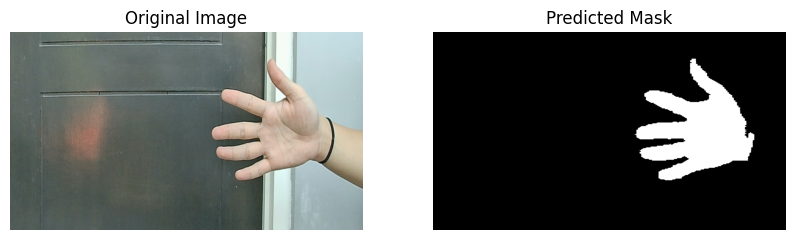

In [42]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def load_and_preprocess_image(image_path, image_size=(256, 256)):
    """
    Loads and preprocesses the image for the model.
    """
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    
    # # Convert TensorFlow image to numpy array for OpenCV processing
    # image_np = image.numpy()
    # # Apply Gaussian filter
    # image_np = cv2.GaussianBlur(image_np, (5, 5), 0)
    # # Convert back to TensorFlow tensor
    # image = tf.convert_to_tensor(image_np)
    
    image = tf.image.resize(image, image_size)
    image = tf.cast(image, tf.float32) / 255.0
    return image

def predict_segmentation(model, image_path, image_size=(256, 256), load_model=True):
    """
    Predicts the segmentation mask for a given image.
    """
    # Load and preprocess the image
    image = load_and_preprocess_image(image_path, image_size)
    image = tf.expand_dims(image, axis=0)  # Add batch dimension

    if load_model:
        model = tf.keras.models.load_model(
            './Semantic-New-Dion/runs/Modified-PoseCNN/weights/Modified_PoseCNN_Semantic_20260703-080226.keras')
        model.summary()

    # Predict the segmentation mask
    predicted_mask = model.predict(image)[0]  # Remove batch dimension
    threshold = 0.7
    binary_mask = (predicted_mask > threshold).astype(np.uint8)
    return binary_mask

def display_image_and_mask(image_path, predicted_mask):
    """
    Displays the original image and the predicted mask.
    """
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB for display

    # Resize the image to match the mask size
    print(predicted_mask.shape)
    predicted_mask_resized = cv2.resize(predicted_mask, (image.shape[1], image.shape[0]))

    # Display the image and mask
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title('Original Image')
    plt.imshow(image)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title('Predicted Mask')
    plt.imshow(predicted_mask_resized, cmap='gray')
    plt.axis('off')

    plt.show()

test_image_path = 'data-extraction/pseudo_dataset_08072026/img_left/amik-vid-1-S-hand-img_2026-07-06_173426__amik-vid-1-S-frame-4-2026-07-06_173426_left_rectified.png'
# test_image_path = 'data/A-splitdataset/test/images/bryan-img-5-M-frame-132-2024-06-07_234942_0.jpg'
# test_image_path = 'data/A-splitdataset/test/images/dion-img-3-M-frame-336-2024-06-07_235425_0.jpg'

# test_image_path = 'data/A-splitdataset/test/images/ema-img-6-M-frame-308-2024-06-07_235705_0.jpg'
# test_image_path = 'data/A-splitdataset/test/images/iwap-img-6-M-frame-204-2024-06-07_235838_0.jpg'
# test_image_path = 'data/A-splitdataset/test/images/umam-img-3-M-frame-395-2024-06-08_000005_0.jpg'

model = model3
# model = tf.keras.models.load_model(
#     './Semantic-New-Dion/Modified-PoseCNN/weights/Modified_PoseCNN_Semantic_20260703-080226.keras')
# model.summary()

# Predict the segmentation mask
predicted_mask = predict_segmentation(model, 
                                      test_image_path, 
                                      image_size=(224, 224), 
                                      load_model=False)

# Display the original image and the predicted mask
display_image_and_mask(test_image_path, predicted_mask)

In [91]:
def create_overlay(
    rgb,
    mask,
    alpha=0.45,
    mask_color=(255, 0, 0)  # merah dalam BGR
):
    print(rgb.shape)
    print(mask.shape)
    h, w = rgb.shape[:2]

    if mask.shape[:2] != (h, w):
        mask = cv2.resize(
            mask,
            (w, h),
            interpolation=cv2.INTER_LINEAR
        )


    if len(mask.shape) == 3 and mask.shape[2] == 1:
        mask = np.squeeze(mask)
    
    binary_mask = mask > 0
    color_layer = np.zeros_like(rgb)    
    color_layer[binary_mask] = mask_color
    
    overlay = rgb.copy()
    overlay[binary_mask] = cv2.addWeighted(
        rgb[binary_mask],
        1.0 - alpha,
        color_layer[binary_mask],
        alpha,
        0
    )
    print(f'Size Input: {rgb.shape[::-1]}')
    print(f'Size Masks: {binary_mask.shape[::-1]}')
    return overlay
    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
(224, 224, 3)
(224, 224)
Size Input: (3, 224, 224)
Size Masks: (224, 224)
(224, 224, 3)
(224, 224, 1)
Size Input: (3, 224, 224)
Size Masks: (224, 224)
(224, 224, 3)
(224, 224, 1)
Size Input: (3, 224, 224)
Size Masks: (224, 224)
(224, 224, 3)
(224, 224, 1)
Size Input: (3, 224, 224)
Size Masks: (224, 224)


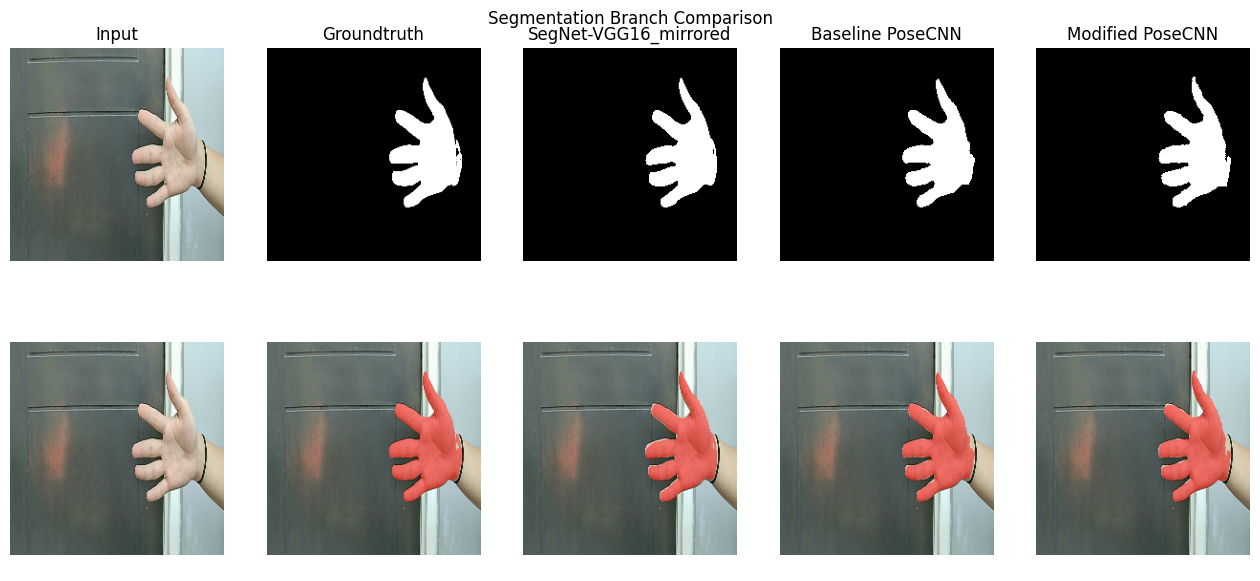

In [113]:
gt_path = r'./data-extraction/pseudo_dataset_08072026/semantic/amik-vid-1-S-hand-img_2026-07-06_173426__amik-vid-1-S-frame-4-2026-07-06_173426_left_rectified_sam_mask.png'

input_image = cv2.cvtColor(cv2.resize(cv2.imread(test_image_path), (224, 224)), cv2.COLOR_BGR2RGB) 
groundtruth = cv2.resize(cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE), (224, 224))
predict1    = predict_segmentation(model1, test_image_path, image_size=(224, 224), load_model=False)
predict2    = predict_segmentation(model2, test_image_path, image_size=(224, 224), load_model=False)
predict3    = predict_segmentation(model3, test_image_path, image_size=(224, 224), load_model=False)
# print("type: ", type(predict1))
overlay_gt  = create_overlay(input_image, groundtruth)
overlay1    = create_overlay(input_image, predict1)
overlay2    = create_overlay(input_image, predict2)
overlay3    = create_overlay(input_image, predict3)

# Display the image and mask
plt.figure(figsize=(16, 7))
plt.title("Segmentation Branch Comparison")
plt.axis('off')

plt.subplot(2, 5, 1)
plt.axis('off')
plt.title('Input')
plt.imshow(input_image)

plt.subplot(2, 5, 2)
plt.title('Groundtruth')
plt.imshow(groundtruth, cmap='gray')
plt.axis('off')

plt.subplot(2, 5, 3)
plt.title('SegNet-VGG16_mirrored')
plt.imshow(predict1, cmap='gray')
plt.axis('off')

plt.subplot(2, 5, 4)
plt.title('Baseline PoseCNN')
plt.imshow(predict2, cmap='gray')
plt.axis('off')

plt.subplot(2, 5, 5)
plt.title('Modified PoseCNN')
plt.imshow(predict3, cmap='gray')
plt.axis('off')

# Display overlays
plt.subplot(2, 5, 6)
plt.imshow(input_image)
plt.axis('off')

plt.subplot(2, 5, 7)
plt.imshow(overlay_gt)
plt.axis('off')

plt.subplot(2, 5, 8)
plt.imshow(overlay1)
plt.axis('off')

plt.subplot(2, 5, 9)
plt.imshow(overlay2)
plt.axis('off')

plt.subplot(2, 5, 10)
plt.imshow(overlay3)
plt.axis('off')

plt.show()
